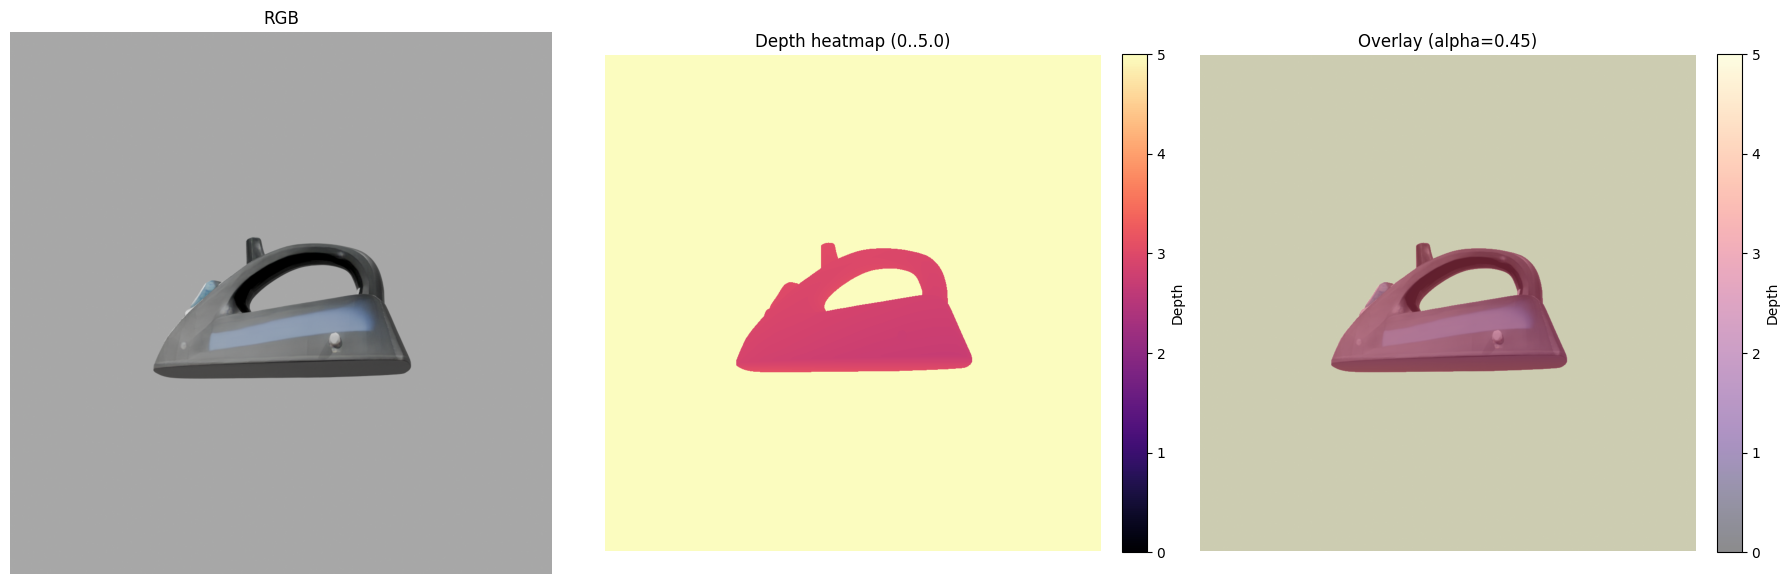

{'vmin': 0.0, 'vmax': 5.0, 'depth_clip_max': 5.0}

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

DEPTH_CLIP_MAX = 5.0
DEPTH_CMAP = "magma"
OVERLAY_ALPHA = 0.45

def _read_exr_depth_openexr(exr_path: str) -> np.ndarray:
    import OpenEXR, Imath
    exr = OpenEXR.InputFile(exr_path)
    header = exr.header()
    dw = header["dataWindow"]
    w = dw.max.x - dw.min.x + 1
    h = dw.max.y - dw.min.y + 1
    ch_names = list(header["channels"].keys())
    ch = "Z" if "Z" in ch_names else ("R" if "R" in ch_names else ch_names[0])
    raw = exr.channel(ch, Imath.PixelType(Imath.PixelType.FLOAT))
    depth = np.frombuffer(raw, dtype=np.float32).reshape(h, w).copy()
    depth[~np.isfinite(depth)] = np.nan
    return depth

def show_rgb_depth(
    rgb_path: str,
    depth_path: str,
    *,
    depth_clip_max: float = DEPTH_CLIP_MAX,
    cmap: str = DEPTH_CMAP,
    alpha: float = OVERLAY_ALPHA,
):
    rgb = np.array(Image.open(rgb_path).convert("RGB"))
    depth = _read_exr_depth_openexr(depth_path)

    depth = np.maximum(depth, 0.0)
    depth_vis = np.clip(depth, 0.0, float(depth_clip_max))

    fig, ax = plt.subplots(1, 3, figsize=(18, 6))

    ax[0].imshow(rgb)
    ax[0].set_title("RGB")
    ax[0].axis("off")

    im_d = ax[1].imshow(depth_vis, cmap=cmap, vmin=0.0, vmax=float(depth_clip_max))
    ax[1].set_title(f"Depth heatmap (0..{depth_clip_max})")
    ax[1].axis("off")
    cb1 = fig.colorbar(im_d, ax=ax[1], fraction=0.046, pad=0.04)
    cb1.set_label("Depth")

    ax[2].imshow(rgb)
    im_o = ax[2].imshow(depth_vis, cmap=cmap, vmin=0.0, vmax=float(depth_clip_max), alpha=alpha)
    ax[2].set_title(f"Overlay (alpha={alpha})")
    ax[2].axis("off")
    cb2 = fig.colorbar(im_o, ax=ax[2], fraction=0.046, pad=0.04)
    cb2.set_label("Depth")

    plt.tight_layout()
    plt.show()

    return {"vmin": 0.0, "vmax": float(depth_clip_max), "depth_clip_max": float(depth_clip_max)}

show_rgb_depth(
    "/my_workspace/4DHHOI/4DHOI/Segment_Mesh/objects/video_01/iron/renders/rgb/az010_el-15.png",
    "/my_workspace/4DHHOI/4DHOI/Segment_Mesh/objects/video_01/iron/renders/depth/az010_el-150001.exr",
)
